In [ ]:
library(ggplot2)
library(data.table)
theme_set(theme_bw())

# Source - https://stackoverflow.com/a
# Posted by dfrankow
# Retrieved 2026-01-16, License - CC BY-SA 3.0

options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)
options(jupyter.plot_scale = 1)

In [2]:
tools = c('singlem', 'sylph', 'singlem_dev', 'singlem_joint', 'singlem_inject')
publication_names = data.table(
    tool = tools,
    publication_name = c('SingleM', 'sylph', 'SingleM dev', 'SingleM joint', 'SingleM inject')
)
communities = paste0('sample',as.character(c(4, 5)))
known_percent = c(0, 10, 50, 70)
d1 = data.table(expand.grid(tool = tools, community = communities, known = known_percent))
d1[, tool2 := publication_names[tool, on = "tool", publication_name]]
# output_singlem/opal/GCA_022615805.1_genomic.opal_report
readit = function(tool, community, known){
    to_read = paste0('output_',tool,'/opal/known', known, '/', community,'.opal_report')
    return(fread(to_read))
}
d2 = d1[known != 0 | tool != "sylph" | community != "sample5", readit(tool, community, known), by=list(tool, community, known, tool2)]

In [3]:
setnames(d2, c('tool', 'community', 'known', 'tool2', 'blah', 'rank', 'metric', 'sample', 'value'))
d3 = d2[blah != 'Gold standard', .(tool, community, known, rank, metric, value, tool2)]
d3[, rank := factor(rank, c('kingdom','phylum','class','order','family','genus','species'))]

In [4]:
s1 = dcast(d3[!is.na(rank)], ...~metric, value.var='value')
s1[, c("tool", "tool2") := list(tool2, NULL)]

s1 = s1[order(rank, tool)]
fwrite(s1, 'opal_summary.csv', sep='\t')

Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_line()`).”


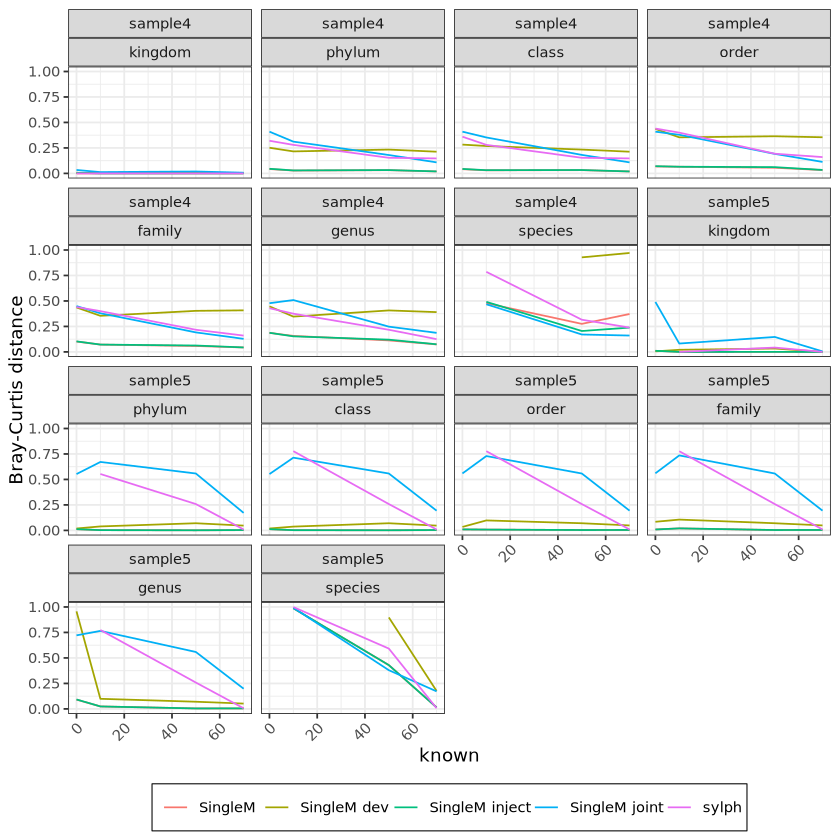

In [22]:
# Remove figure legend title, and put the legend in bottom left of plot, with a bounding box
ggplot(s1, aes(known, `Bray-Curtis distance`, colour = tool)) +
   geom_line() +
   theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
   theme(legend.title=element_blank()) +
   theme(legend.position="bottom") +
   theme(legend.background = element_rect(colour = "black", linewidth = 0.3)) +
   facet_wrap(vars(community, rank))

# Relationship between relative abundance and accuracy

In [6]:
truth_profiles = data.table(expand.grid(community=communities, known=known_percent))
truth_profiles2 = truth_profiles[
    ,
    fread(paste('truths/known', known, '/',community,'.condensed',sep=''),
          colClasses = c("coverage" = "double")),
    by=list(community, known)
]
truth_profiles2[, c("sample", "tool") := .(NULL, 'Gold standard')]

In [7]:
tool_profiles = data.table(expand.grid(tool = tools, community = communities, known = known_percent))
tool_profiles2 = tool_profiles[
    ,
    fread(paste('output_',tool,'/',tool,'/known', known, '/', community,'.profile',sep='')),
    by=list(tool, community, known)
]
tool_profiles2[
    ,
    `:=`(sample = NULL,
         taxonomy = gsub('Root;','',gsub('; ',';',taxonomy)),
         tool = factor(publication_names[tool, on = "tool", publication_name]))
]

all_profiles = rbind(truth_profiles2, tool_profiles2)
all_profiles[, relabu := coverage / sum(coverage), by = list(community, known, tool)]
m = dcast(all_profiles, taxonomy + community + known ~ tool, value.var = c("relabu", "coverage"), fill = 0)
setnames(m, names(m), gsub("_", "__", names(m)))
setnames(m, c("relabu__Gold standard", "coverage__Gold standard"), c("true_relabu", "true_coverage"))

In [8]:
# singlem and sylph relative abundances
format_table <- function(m) {
    ra_cols <- grep("^relabu_|_relabu$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^coverage_|_coverage$", names(m))), with = FALSE]
    mtmp[
        ,
        c(ra_cols, "taxonomy") := c(
            lapply(.SD, scales::label_percent()),
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = ra_cols
    ][order(community, known, taxonomy)]
}

In [9]:
# singlem coverages
format_table_cov <- function(m) {
    cov_cols <- grep("^coverage_|_coverage$", names(m), value = TRUE)
    mtmp = m[, which(!grepl("^relabu_|_relabu$", names(m))), with = FALSE]
    mtmp[
        ,
        c(cov_cols, "taxonomy") := c(
            .SD,
            list(purrr::map_chr(strsplit(taxonomy, "; ?"), function(x) paste0(tail(x,2), collapse = "; ")))
        ),
        .SDcols = cov_cols
    ][order(community, known, taxonomy)]
}

In [10]:
# kingdom
#format_table(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";p__.*", "", taxonomy))])
format_table_cov(m[grep("d__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";p__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,d__Archaea,0.0,0.00,0.45,0.43,1.42,0.000
sample4,0,d__Bacteria,75.0,75.39,72.43,75.40,40.70,15.543
sample4,10,d__Archaea,0.0,0.00,0.23,0.00,0.44,0.000
sample4,10,d__Bacteria,75.0,71.74,69.93,71.75,34.08,22.766
sample4,50,d__Archaea,0.0,0.00,0.41,0.00,0.88,0.000
sample4,50,d__Bacteria,75.0,72.85,69.84,72.88,45.95,47.151
sample4,70,d__Archaea,0.0,0.00,0.31,0.00,0.40,0.000
sample4,70,d__Bacteria,75.0,76.00,73.24,76.02,58.13,57.771
sample5,0,d__Archaea,1000.0,973.68,987.53,973.68,9.24,0.000


In [11]:
# phylum
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";c__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";p__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";c__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,d__Bacteria; p__Acidobacteriota,3.0,3.07,0.10,3.08,3.36,0.000
sample4,0,d__Bacteria; p__Actinobacteriota,39.0,37.41,31.74,37.41,4.66,9.555
sample4,0,d__Bacteria; p__Bacteroidota,9.0,7.84,1.12,7.85,10.15,0.000
sample4,0,d__Bacteria; p__Bdellovibrionota,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,d__Bacteria; p__Campylobacterota,3.0,3.41,1.11,3.41,2.38,0.000
sample4,0,d__Bacteria; p__Chlamydiota,3.0,1.99,0.00,1.82,2.46,0.000
sample4,0,d__Bacteria; p__Desulfobacterota,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,d__Bacteria; p__Desulfobacterota_B,0.0,0.00,0.00,0.00,0.09,0.000
sample4,0,d__Bacteria; p__Firmicutes_A,6.0,5.91,0.34,5.91,6.58,0.000


In [12]:
# class
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";o__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";c__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";o__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,p__Acidobacteriota; c__Holophagae,0.0,0.00,0.00,0.00,0.09,0.000
sample4,0,p__Acidobacteriota; c__UBA4820,3.0,2.96,0.10,2.97,3.20,0.000
sample4,0,p__Acidobacteriota; c__Vicinamibacteria,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,p__Actinobacteriota; c__Actinomycetia,39.0,37.41,31.74,37.41,4.66,9.555
sample4,0,p__Bacteroidota; c__Bacteroidia,6.0,5.51,1.12,5.52,7.76,0.000
sample4,0,p__Bacteroidota; c__Ignavibacteria,3.0,2.22,0.00,2.22,2.39,0.000
sample4,0,p__Bdellovibrionota; c__Bdellovibrionia,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,p__Campylobacterota; c__Campylobacteria,3.0,3.41,1.11,3.41,2.38,0.000
sample4,0,p__Chlamydiota; c__Chlamydiia,3.0,1.99,0.00,1.82,2.46,0.000


In [13]:
# order
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";f__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";o__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";f__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,c__Actinomycetia; o__Mycobacteriales,3.0,2.84,0.00,2.84,0.99,0.000
sample4,0,c__Actinomycetia; o__Streptomycetales,36.0,31.29,26.76,31.29,3.67,9.555
sample4,0,c__Alphaproteobacteria; o__RF32,3.0,3.13,0.64,3.12,2.99,0.000
sample4,0,c__Bacteroidia; o__Bacteroidales,3.0,2.89,0.00,2.91,4.86,0.000
sample4,0,c__Bacteroidia; o__Cytophagales,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,c__Bacteroidia; o__Flavobacteriales,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,c__Bacteroidia; o__NS11-12g,3.0,1.99,0.00,1.98,2.55,0.000
sample4,0,c__Bacteroidia; o__Sphingobacteriales,0.0,0.00,0.00,0.00,0.21,0.000
sample4,0,c__Bdellovibrionia; o__Bdellovibrionales,0.0,0.00,0.00,0.00,0.07,0.000


In [14]:
# family
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";g__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";f__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";g__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,o__4484-93; f__4484-93,0.0,0.00,0.00,0.00,0.07,0.000
sample4,0,o__Bacteroidales; f__Bacteroidaceae,3.0,2.26,0.00,2.26,3.03,0.000
sample4,0,o__Bacteroidales; f__F082,0.0,0.00,0.00,0.00,0.05,0.000
sample4,0,o__Bacteroidales; f__Marinifilaceae,0.0,0.00,0.00,0.00,0.09,0.000
sample4,0,o__Bacteroidales; f__Marinilabiliaceae,0.0,0.00,0.00,0.00,0.15,0.000
sample4,0,o__Bacteroidales; f__Muribaculaceae,0.0,0.00,0.00,0.00,0.71,0.000
sample4,0,o__Bacteroidales; f__Paludibacteraceae,0.0,0.00,0.00,0.00,0.41,0.000
sample4,0,o__Bacteroidales; f__Tannerellaceae,0.0,0.00,0.00,0.00,0.27,0.000
sample4,0,o__Bacteroidales; f__UBA7960,0.0,0.00,0.00,0.00,0.15,0.000


In [15]:
# How well does genus level rescue some of the missing genomes? First need to remake the table with genus level, annoying since kraken profiles are filled, when the rest aren't.
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";s__.*", "", taxonomy))])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";g__", taxonomy), lapply(.SD, sum), by = list(community, known, taxonomy = gsub(";s__.*", "", taxonomy))])

community,known,taxonomy,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<fct>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
sample4,0,f__2-02-FULL-66-22; g__2-02-FULL-66-22,0,0.00,0.00,0.00,0.07,0.000
sample4,0,f__4484-93; g__4484-93,0,0.00,0.00,0.00,0.07,0.000
sample4,0,f__Bacteroidaceae; g__Alloprevotella,0,0.00,0.00,0.00,0.55,0.000
sample4,0,f__Bacteroidaceae; g__Bacteroides,0,0.00,0.00,0.00,0.49,0.000
sample4,0,f__Bacteroidaceae; g__Bacteroides_G,0,0.00,0.00,0.00,0.06,0.000
sample4,0,f__Bacteroidaceae; g__Bacteroides_H,0,0.00,0.00,0.00,0.12,0.000
sample4,0,f__Bacteroidaceae; g__JAAYUD01,0,0.00,0.00,0.00,0.06,0.000
sample4,0,f__Bacteroidaceae; g__OM05-12,0,0.00,0.00,0.00,0.22,0.000
sample4,0,f__Bacteroidaceae; g__Phocaeicola,0,0.00,0.00,0.00,0.36,0.000


In [16]:
# Species level
#format_table(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])
format_table_cov(m[!grepl("d__Archaea", taxonomy) & grepl(";s__", taxonomy)])

taxonomy,community,known,true_coverage,coverage__SingleM,coverage__SingleM dev,coverage__SingleM inject,coverage__SingleM joint,coverage__sylph
<chr>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
g__Actinomycetospora; s__Actinomycetospora chiangmaiensis,sample4,0,0e+00,0.00,0.00,0.00,0.23,0.000
g__Actinomycetospora; s__Actinomycetospora sp012933465,sample4,0,0e+00,0.72,0.00,0.72,0.34,0.000
g__BACL14; s__BACL14 sp000156155,sample4,0,0e+00,1.24,0.00,1.24,1.67,2.858
g__BACL14; s__BACL14 sp001044335,sample4,0,0e+00,0.00,0.00,0.00,0.27,0.000
g__BACL14; s__BACL14 sp010023085,sample4,0,0e+00,0.00,0.00,0.00,0.18,0.000
g__Caccovicinus; s__Caccovicinus sp910589195,sample4,0,0e+00,0.00,0.00,0.00,0.47,0.000
g__Streptomyces; s__Streptomyces paradoxus,sample4,0,0e+00,0.00,0.00,2.27,0.72,3.315
g__Streptomyces; s__Streptomyces somaliensis,sample4,0,0e+00,0.00,0.00,2.12,1.60,3.101
g__Streptomyces; s__Streptomyces sp008042275,sample4,0,0e+00,0.00,0.00,2.15,1.35,3.139
